# Wigner Negativity of |1⟩ Under Random Displacement Noise

The single-photon Fock state $|1\rangle$ has a Wigner function that is **negative at the origin** — a signature of non-classicality with no classical phase-space analogue:

$$W_1(q, p) = \frac{1}{\pi}\left(2(q^2 + p^2) - 1\right)e^{-(q^2 + p^2)}, \qquad W_1(0,0) = -\frac{1}{\pi} \approx -0.318.$$
or if $$q= \sqrt{2}Q $$ and $$ p= \sqrt{2}P$$:
$$W_1(Q, P) = \frac{2}{\pi}\left(4(Q^2 + P^2) - 1\right)e^{-2(Q^2 + P^2)}$$

A random-displacement error channel convolves the Wigner function with the Gaussian noise distribution

$$P(\beta) = \frac{1}{\pi\sigma^2}\,e^{-(\beta_R^2 + \beta_I^2)/\sigma^2},$$

which has per-quadrature variance $\sigma^2$. The noisy Wigner function is

$$W_\text{noisy}(Q, P) = \iint P(\beta_R, \beta_I)\, W_1(Q - \beta_R,\, P - \beta_I)\, \beta_R\, \beta_I.$$

Evaluating the convolution in closed form:

$$W_\text{noisy}(Q, P) = 2\frac{e^{-2(Q^2 + P^2)/(1 + 2\sigma^2)}\left(-1 + 4Q^2 + 4P^2 + 4\sigma^4\right)}{\pi\,(1 + 2\sigma^2)^3}.$$

The dip stays at the origin for all $\sigma$, so the depth of the negativity is

$$W_\text{noisy}(0, 0) = \frac{8\sigma^4 - 2}{\pi\,(1 + 2\sigma^2)^3}.$$

This rises monotonically from $-1/\pi$ and reaches zero at the **negativity threshold**

$$\sigma^* = \frac{1}{\sqrt{2}} \approx 0.707,$$

beyond which the state has no Wigner negativity and the displacement channel has fully erased its non-classicality.

In [153]:
import sympy as sp
Q, P, alpha, beta , t, s= sp.symbols('Q P alpha beta t s', real=True)
sigma = sp.symbols('sigma', positive=True)

gr = sp.exp(-beta**2/sigma**2)/(sp.sqrt(sp.pi)*sigma)
gi = sp.exp(-beta**2/sigma**2)/(sp.sqrt(sp.pi)*sigma)
w1 = sp.exp(-2*(t-beta)**2)
w2 = sp.exp(-2*(t-beta)**2)*4*(t-beta)**2

A = sp.integrate(gr*w1, (beta, -sp.oo, sp.oo))
B = sp.integrate(gr*w2, (beta, -sp.oo, sp.oo))



In [154]:
Aq, Ap = A.subs(t, Q), A.subs(t, P)
Bq, Bp = B.subs(t, Q), B.subs(t, P)
W_noisy_analytical = sp.simplify(2*(Bq*Ap + Aq*Bp - Aq*Ap)/sp.pi)

sp.integrate(gr, (beta, -sp.oo, sp.oo))            # -> 1  (Gaussian normalized)
sp.simplify(W_noisy_analytical.subs({Q:0, P:0}))           # -> (2*sigma**2 - 1)/(pi*(2*sigma**2 + 1)**2)

# negativity is deepest at the origin, so evaluate W_noisy there
W00 = sp.simplify(W_noisy_analytical.subs({Q: 0, P: 0}))
print(W00)                       # (4*sigma**4 - 1)/(pi*(2*sigma**2 + 1)**3)

# threshold: solve for the sigma where the negativity vanishes
sigma_star = sp.solve(sp.Eq(W00, 0), sigma)
print(sigma_star)                # [sqrt(2)/2]  ==  1/sqrt(2)
W_noisy_analytical

2*(2*sigma**2 - 1)/(pi*(4*sigma**4 + 4*sigma**2 + 1))
[sqrt(2)/2]


(8*P**2 + 8*Q**2 + 8*sigma**4 - 2)*exp((-P**2 + P**2/(2*sigma**2 + 1) - Q**2 + Q**2/(2*sigma**2 + 1))/sigma**2)/(pi*(8*sigma**6 + 12*sigma**4 + 6*sigma**2 + 1))

In [155]:
R = sp.symbols('R', nonnegative=True)
u = sp.symbols('u', real=True)                              # u stands for R^2 = Q^2 + P^2
R2max = sp.solve(W_noisy.subs({Q: sp.sqrt(u), P: 0}), u)[0]
                           # W_noisy < 0 inside R^2 < this
Wrad  = W_noisy_analytical.subs({Q: R, P: 0})                      # radial profile (P=0, Q=R)
N = sp.simplify(-sp.integrate(Wrad*2*sp.pi*R, (R, 0, sp.sqrt(R2max))))



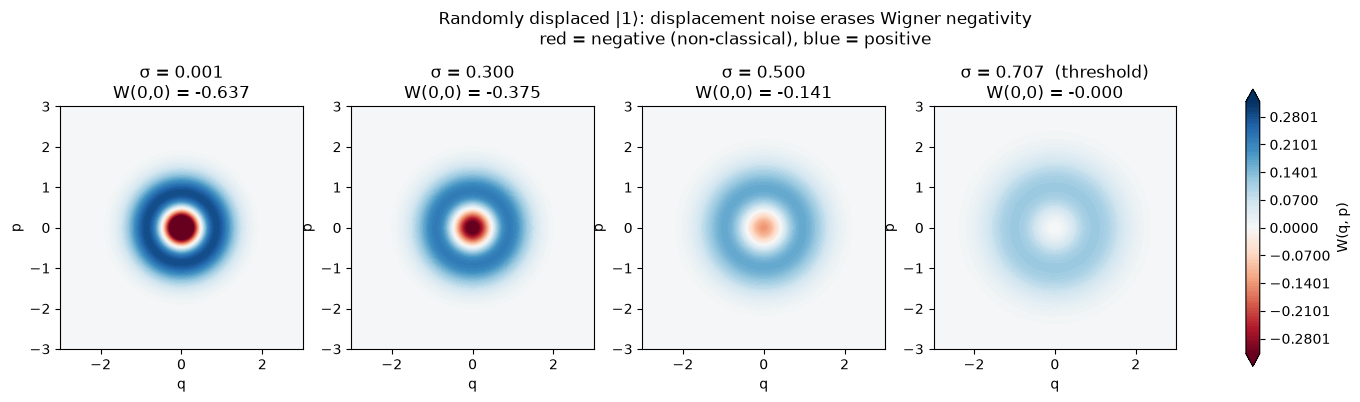

In [156]:
import numpy as np
import matplotlib.pyplot as plt 
# symbolic -> numeric, now a function of Q, P, and sigma
W_func = sp.lambdify((Q, P, sigma), W_noisy, 'numpy')

# phase-space grid  (lowercase names so we don't clobber the SymPy symbols Q, P)
L, N = 4.0, 400
xs = np.linspace(-L, L, N)
Qg, Pg = np.meshgrid(xs, xs)

sigmas = [1e-3, 0.3, 0.5, 1/np.sqrt(2)]
vmax   = 1/np.pi
levels = np.linspace(-vmax, vmax, 101)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, s in zip(axes, sigmas):
    W  = W_func(Qg, Pg, s)                          # <- from lambdify, not a hand-typed formula
    im = ax.contourf(Qg, Pg, W, levels=levels, cmap='RdBu', extend='both')
    tag = '  (threshold)' if abs(s - 1/np.sqrt(2)) < 1e-6 else ''
    ax.set_title(f'σ = {s:.3f}{tag}\nW(0,0) = {W_func(0.0, 0.0, s):+.3f}')
    ax.set_xlabel('q'); ax.set_ylabel('p')
    ax.set_aspect('equal'); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
fig.colorbar(im, ax=axes, shrink=0.8, label='W(q, p)')
fig.suptitle('Randomly displaced |1⟩: displacement noise erases Wigner negativity\n'
             'red = negative (non-classical), blue = positive', fontsize=12)
plt.savefig('wigner_negativity_vs_sigma.pdf', bbox_inches='tight')
plt.show()

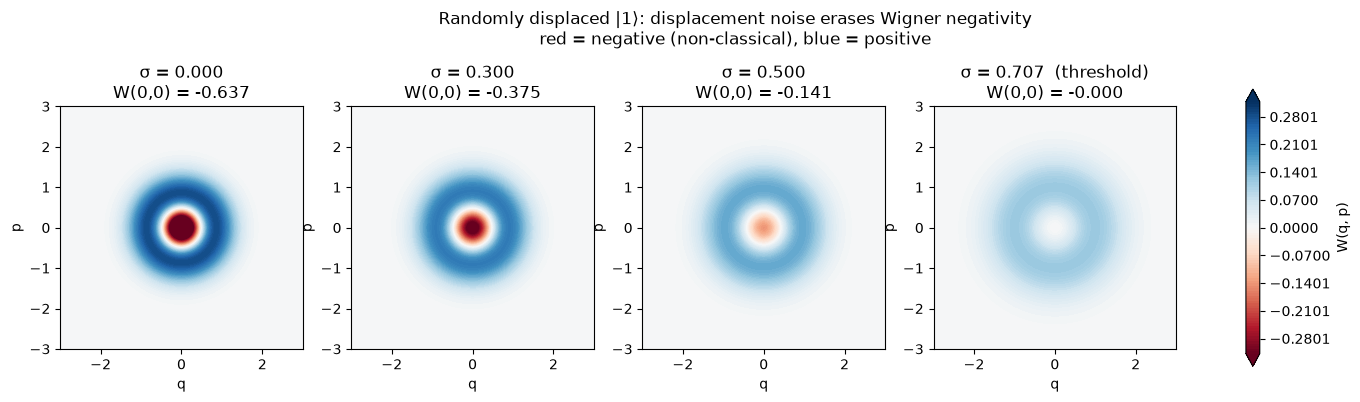

In [159]:
import numpy as np
import matplotlib.pyplot as plt

def W_noisy(q, p, sigma):
    """Exact Wigner function of a randomly displaced |1>, per-quadrature noise variance sigma^2."""
    D  = 1 + 2*sigma**2
    r2 = q**2 + p**2
    return np.exp(-2*r2/D) * (-2 + 8*r2 + 8*sigma**4) / (np.pi * D**3)

# phase-space grid
L, N = 4.0, 400
x = np.linspace(-L, L, N)
Q, P = np.meshgrid(x, x)

sigmas = [0.0, 0.3, 0.5, 1/np.sqrt(2)]     # last panel is the threshold sigma*
vmax   = 1/np.pi                            # fixed scale so the shrinking dip is comparable across panels
levels = np.linspace(-vmax, vmax, 101)      # symmetric -> 0 maps to white

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, s in zip(axes, sigmas):
    W  = W_noisy(Q, P, s)
    im = ax.contourf(Q, P, W, levels=levels, cmap='RdBu', extend='both')
    tag = '  (threshold)' if abs(s - 1/np.sqrt(2)) < 1e-6 else ''
    ax.set_title(f'σ = {s:.3f}{tag}\nW(0,0) = {W_noisy(0,0,s):+.3f}')
    ax.set_xlabel('q'); ax.set_ylabel('p')
    ax.set_aspect('equal'); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

fig.colorbar(im, ax=axes, shrink=0.8, label='W(q, p)')
fig.suptitle('Randomly displaced |1⟩: displacement noise erases Wigner negativity\n'
             'red = negative (non-classical), blue = positive', fontsize=12)
plt.savefig('wigner_negativity_vs_sigma.pdf', bbox_inches='tight')
plt.show()

After the squeezing correction, the error distribution becomes anisotropic:
$$P(\beta) = \frac{1}{\pi\sigma^2}\,\exp\!\left(-\frac{\beta_R^2}{\left(\sigma e^{2s}\right)^2} - \frac{(\beta_I+m)^2}{\left(\sigma e^{-2s}\right)^2}\right)(1 + sin(4 \alpha (\beta_I+m))),$$

In [160]:
# integral of a normalized Gaussian must be 1
from scipy import integrate      # this 'integrate' is SciPy's module
sigma = 0.3
g = lambda b: np.exp(-b**2/sigma**2)/(np.sqrt(np.pi)*sigma)
val, err = integrate.quad(g, -8, 8)
print(val, err)      # -> 1.0000..., err ~1e-11

1.0000000000000002 4.504193448881706e-10


Step 1 — write the two ingredients as ordinary functions. The corrected error distribution and the ideal Wigner function, as plain NumPy (no SymPy):

In [161]:
def params(sigma):
    s     = (1/8)*np.log(1 - np.exp(-1))
    wR    = sigma*np.exp(2*s)
    wI    = sigma*np.exp(-2*s)
    alpha = 1/(np.sqrt(8)*wI)
    m     = 2*alpha*wI**2*np.exp(-4*alpha**2*wI**2)
    return wR, wI, alpha, m

def P(bR, bI, sigma):
    wR, wI, alpha, m = params(sigma)
    gR = np.exp(-bR**2/wR**2)/(np.sqrt(np.pi)*wR)
    gI = np.exp(-(bI+m)**2/wI**2)/(np.sqrt(np.pi)*wI)
    return gR*gI*(1 + np.sin(4*alpha*(bI+m)))

def W1(x, y, sigma):                                   # ideal |1>, coeff-4 convention
    r2 = x**2 + y**2
    return (2/np.pi)*(4*r2 - 1)*np.exp(-2*r2)

Step 2 — compute one value of 𝑊_corr by 2D integration. This is the definition, done directly — the clearest version, even if slow:

In [163]:
def W_corr_point(Q, Pp, sigma):
    integrand = lambda bI, bR: P(bR, bI, sigma) * W1(Q - bR, Pp - bI, sigma)
    val, err = integrate.dblquad(integrand, -8, 8, -8, 8)
    return val

print(W_corr_point(0, 0, 0.3))     # -> -0.4230...

-0.4230015835417278


One trap here: dblquad expects the integrand as func(inner, outer) — the inner variable comes first in the function signature. I wrote lambda bI, bR: so bR is the outer variable (limits -8, 8 given first) and bI the inner. Get that order backwards and you integrate the wrong way — harmless for symmetric limits like these, but a real bug once limits differ. The result 

−0.423 matches, so the setup is right.

Step 3 — the speed problem. W_corr_point does a full 2D integral for one (𝑄,𝑃)
(Q,P). A plotting grid is 400×400=160,000 points; that's 160,000 two-dimensional integrations. Minutes to hours. Correct, but impractical for a figure.

Step 4 — factorize to make it fast. The fix uses structure, not a different method. Both 𝑃  and 𝑊1 separate into a 𝛽𝑅​ -part times a 𝛽𝐼 -part, so the 2D integral splits into products of 1D integrals. You compute four 1D arrays along the axis and combine them, instead of integrating over the whole plane at every point:

In [164]:
def W_corr_sq(Qg, Pg, sigma):
    # zero noise: P is a delta, so the corrected state is just the ideal |1>
    if sigma == 0:
        r2 = Qg**2 + Pg**2
        return (2/np.pi)*(4*r2 - 1)*np.exp(-2*r2)

    wR, wI, alpha, m = params(sigma)
    axis = Qg[0, :]
    gR = lambda b: np.exp(-b**2/wR**2)/(np.sqrt(np.pi)*wR)
    pI = lambda b: np.exp(-(b+m)**2/wI**2)/(np.sqrt(np.pi)*wI)*(1 + np.sin(4*alpha*(b+m)))
    aR = np.array([integrate.quad(lambda b: gR(b)*np.exp(-2*(x-b)**2),            -8, 8)[0] for x in axis])
    bR = np.array([integrate.quad(lambda b: gR(b)*4*(x-b)**2*np.exp(-2*(x-b)**2), -8, 8)[0] for x in axis])
    aI = np.array([integrate.quad(lambda b: pI(b)*np.exp(-2*(x-b)**2),            -8, 8)[0] for x in axis])
    bI = np.array([integrate.quad(lambda b: pI(b)*4*(x-b)**2*np.exp(-2*(x-b)**2), -8, 8)[0] for x in axis])
    AQ, AP = np.meshgrid(aR, aI)
    BQ, BP = np.meshgrid(bR, bI)
    return (2/np.pi)*(BQ*AP + AQ*BP - AQ*AP)

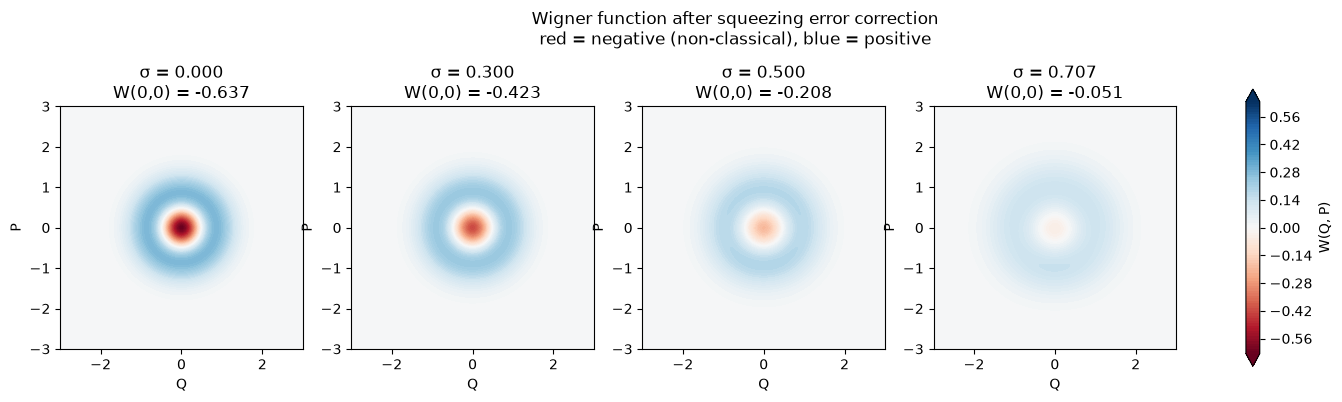

In [143]:
# grid — odd N so the center is exactly (0,0)
L, N = 4.0, 401
x = np.linspace(-L, L, N)
Qg, Pg = np.meshgrid(x, x)
c = N // 2

sigmas = [0, 0.3, 0.5, 1/np.sqrt(2)]     # sigma=0 is singular for the correction
vmax   = 2/np.pi                            # coeff-4 convention: |W1(0,0)| = 2/pi
levels = np.linspace(-vmax, vmax, 101)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, s in zip(axes, sigmas):
    W  = W_corr_sq(Qg, Pg, s)
    im = ax.contourf(Qg, Pg, W, levels=levels, cmap='RdBu', extend='both')
    ax.set_title(f'σ = {s:.3f}\nW(0,0) = {W[c, c]:+.3f}')
    ax.set_xlabel('Q'); ax.set_ylabel('P')
    ax.set_aspect('equal'); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

fig.colorbar(im, ax=axes, shrink=0.8, label='W(Q, P)')
fig.suptitle('Wigner function after squeezing error correction\n'
             'red = negative (non-classical), blue = positive', fontsize=12)
plt.savefig('wigner_corrected_vs_sigma.pdf', bbox_inches='tight')
plt.show()

2 qubit case:


In [165]:
def params_2q(sigma):
    alpha = 1/(np.sqrt(8)*sigma)
    mi     = 2*alpha*sigma**2*np.exp(-4*alpha**2*sigma**2)
    mr     = -2*alpha*sigma**2*np.exp(-4*alpha**2*sigma**2)
    return alpha, mi, mr

def P_2q(bR, bI, sigma):
    alpha, mi, mr = params(sigma)
    gR = np.exp(-(bR+mr)**2/sigma**2)/(np.sqrt(np.pi)*sigma)
    gI = np.exp(-(bI+mi)**2/sigma**2)/(np.sqrt(np.pi)*sigma)
    return gR*gI*(1 + np.sin(4*alpha*(bI+mi)))*(1 - np.sin(4*alpha*(bR+mr)))

In [166]:
def W_corr_2q(Qg, Pg, sigma):
    # zero noise: P is a delta, so the corrected state is just the ideal |1>
    if sigma == 0:
        r2 = Qg**2 + Pg**2
        return (2/np.pi)*(4*r2 - 1)*np.exp(-2*r2)

    alpha, mi, mr = params_2q(sigma)
    axis = Qg[0, :]
    gR = lambda b: np.exp(-(b+mr)**2/sigma**2)/(np.sqrt(np.pi)*sigma)*(1 - np.sin(4*alpha*(b+mr)))
    pI = lambda b: np.exp(-(b+mi)**2/sigma**2)/(np.sqrt(np.pi)*sigma)*(1 + np.sin(4*alpha*(b+mi)))
    aR = np.array([integrate.quad(lambda b: gR(b)*np.exp(-2*(x-b)**2),            -8, 8)[0] for x in axis])
    bR = np.array([integrate.quad(lambda b: gR(b)*4*(x-b)**2*np.exp(-2*(x-b)**2), -8, 8)[0] for x in axis])
    aI = np.array([integrate.quad(lambda b: pI(b)*np.exp(-2*(x-b)**2),            -8, 8)[0] for x in axis])
    bI = np.array([integrate.quad(lambda b: pI(b)*4*(x-b)**2*np.exp(-2*(x-b)**2), -8, 8)[0] for x in axis])
    AQ, AP = np.meshgrid(aR, aI)
    BQ, BP = np.meshgrid(bR, bI)
    return (2/np.pi)*(BQ*AP + AQ*BP - AQ*AP)

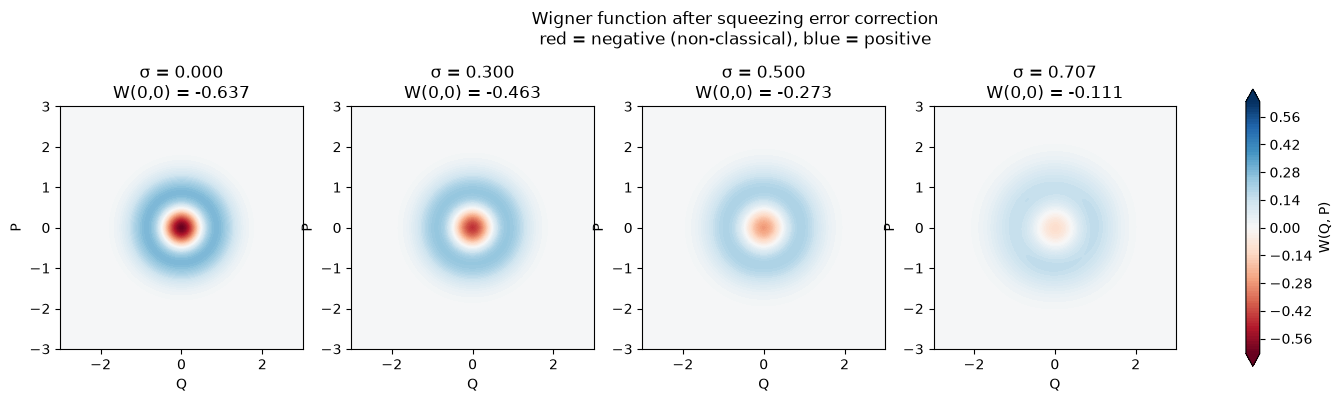

In [139]:
# grid — odd N so the center is exactly (0,0)
L, N = 4.0, 401
x = np.linspace(-L, L, N)
Qg, Pg = np.meshgrid(x, x)
c = N // 2

sigmas = [0, 0.3, 0.5, 1/np.sqrt(2)]     # sigma=0 is singular for the correction
vmax   = 2/np.pi                            # coeff-4 convention: |W1(0,0)| = 2/pi
levels = np.linspace(-vmax, vmax, 101)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, s in zip(axes, sigmas):
    W  = W_corr_2q(Qg, Pg, s)
    im = ax.contourf(Qg, Pg, W, levels=levels, cmap='RdBu', extend='both')
    ax.set_title(f'σ = {s:.3f}\nW(0,0) = {W[c, c]:+.3f}')
    ax.set_xlabel('Q'); ax.set_ylabel('P')
    ax.set_aspect('equal'); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

fig.colorbar(im, ax=axes, shrink=0.8, label='W(Q, P)')
fig.suptitle('Wigner function after squeezing error correction\n'
             'red = negative (non-classical), blue = positive', fontsize=12)
plt.savefig('wigner_corrected_vs_sigma.pdf', bbox_inches='tight')
plt.show()

In [167]:
import numpy as np
import matplotlib.pyplot as plt

def cross_section(Wfunc, q_axis, sigma):
    """W(q, 0) along the q-axis. q_axis must have odd length so the middle row is p=0."""
    Qg, Pg = np.meshgrid(q_axis, q_axis)
    W = Wfunc(Qg, Pg, sigma)
    return W[len(q_axis)//2, :]           # the p = 0 row

def origin_value(Wfunc, sigma):
    """W(0,0) for the vs-sigma panel."""
    q = np.array([-1e-6, 0.0, 1e-6])       # tiny 3-point grid centered on 0
    return cross_section(Wfunc, q, sigma)[1]

In [ ]:

schemes = {
    'Clean |1⟩':               dict(color='blue',   marker=None, func=W1),
    'No QEC':                  dict(color='orange', marker='o',  func=W_noisy),
    'Squeezing + 1-qubit QEC': dict(color='green',  marker='s',  func=W_corr_sq),
    '2-qubit QEC':             dict(color='red',    marker='^',  func=W_corr_2q),
}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

q = np.linspace(-3, 3, 401)                 # odd length -> middle row is p=0
s_slice = 0.7
for name, sc in schemes.items():
    W = cross_section(sc['func'], q, s_slice)
    axL.plot(q, W, color=sc['color'], lw=2, label=name)

# shade where the *best* scheme is negative (here the 2-qubit one)
Wbest = cross_section(schemes['2-qubit QEC']['func'], q, s_slice)
axL.fill_between(q, Wbest, 0, where=(Wbest < 0), color='blue', alpha=0.12)

axL.axhline(0, color='gray', ls='--', lw=0.7)
axL.set_xlabel('q  (cross-section at p = 0)'); axL.set_ylabel('W(q, 0)')
axL.set_title(f'Wigner cross-section at σ = {s_slice}\nQEC deepens the negative dip')
axL.legend()

sigmas = np.linspace(0.05, 1.35, 27)        # sweep; start >0 (correction singular at 0)

for name, sc in schemes.items():
    if name == 'Clean |1⟩':                 # constant, skip in the sweep
        continue
    vals = [origin_value(sc['func'], s) for s in sigmas]
    axR.plot(sigmas, vals, color=sc['color'], marker=sc['marker'], ms=4, label=name)

# optional analytical no-QEC overlay (dashed) if you have the closed form
#axR.plot(sigmas, W00_noqec_analytic(sigmas), 'k--', lw=1, label='No QEC (analytical)')

axR.axhline(0, color='gray', ls='--', lw=0.7)
axR.axvline(1/np.sqrt(2), color='gray', ls=':', lw=1, label=r'$\sigma^*=1/\sqrt2\approx0.707$')
axR.set_xlabel('σ  (displacement noise strength)'); axR.set_ylabel('W(0, 0)')
axR.set_title('Negativity at origin vs σ\nQEC shifts the threshold to higher noise')
axR.legend()

fig.suptitle('QEC preserves Wigner negativity of |1⟩ over a wider noise range', fontsize=13)
plt.tight_layout()
plt.savefig('qec_negativity_comparison.pdf', bbox_inches='tight')
plt.show()

ValueError: 
\sigma^*=1/\sqrt2\approx0.707
                ^
ParseSyntaxException: Expected \sqrt{value}, found '2'  (at char 16), (line:1, col:17)

Error in callback <function _draw_all_if_interactive at 0x11faa7f60> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
\sigma^*=1/\sqrt2\approx0.707
                ^
ParseSyntaxException: Expected \sqrt{value}, found '2'  (at char 16), (line:1, col:17)

ValueError: 
\sigma^*=1/\sqrt2\approx0.707
                ^
ParseSyntaxException: Expected \sqrt{value}, found '2'  (at char 16), (line:1, col:17)

<Figure size 1400x500 with 2 Axes>